In [1]:
import pandas as pd 
import numpy as np
import torch
from collections import OrderedDict
from typing import Dict, List, Tuple

In [2]:
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = r"C:\Users\s2\Documents\Federated\dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    "malgenome": f"{BASE_DIR}/malgenome.csv",
    "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}


# %%
# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data


def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data


def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data


def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()


def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y


In [3]:
from dataset import split_and_prepare_data
# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"  # sesuaikan dengan nama kolom label sebenarnya di file Drebin
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"
 
data = load_raw(PATHS["drebin"])
 
if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = data[SPECIAL_COLUMN].replace("?", np.nan)
    data[SPECIAL_COLUMN] = pd.to_numeric(data[SPECIAL_COLUMN], errors="coerce")
 
if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")
 
data = encode_label(data, LABEL_COLUMN, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COLUMN)
data = data.dropna().reset_index(drop=True)
 
X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]
 
report("Drebin", X_drebin, y_drebin)
print("Jumlah kelas:", N_CLASSES)
 
drebin_split = split_and_prepare_data(X_drebin, y_drebin)
 
 
# %%
# =============================================================================
# 2. Dataset KronoDroid
# =============================================================================
LABEL_COL_KRONO = "Malware"
 
data = load_raw(PATHS["kronodroid"])
print("Ukuran data awal:", data.shape)
print("\nMissing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("\nNilai unik Malware:", data[LABEL_COL_KRONO].unique())
print("Distribusi kelas Malware:\n", data[LABEL_COL_KRONO].value_counts())
 
data = to_numeric_features(data, LABEL_COL_KRONO)
data = data.dropna().reset_index(drop=True)
 
X_krono, y_krono = split_features_labels(data, LABEL_COL_KRONO)
target_names_krono = ["goodware", "malware"]
 
report("KronoDroid", X_krono, y_krono)
print("Jumlah fitur:", X_krono.shape[1])
 
krono_split = split_and_prepare_data(X_krono, y_krono)
 
 
# %%
# =============================================================================
# 3. Dataset MalGenome
# =============================================================================
LABEL_COL_MALGENOME = "class"
 
data = load_raw(PATHS["malgenome"])
print("Missing value per kolom:\n", data.isna().sum())
 
data = encode_label(data, LABEL_COL_MALGENOME, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COL_MALGENOME)
data = data.dropna().reset_index(drop=True)
 
X_malgenome, y_malgenome = split_features_labels(data, LABEL_COL_MALGENOME)
target_names_malgenome = ["benign", "malware"]
 
report("MalGenome", X_malgenome, y_malgenome)
 
malgenome_split = split_and_prepare_data(X_malgenome, y_malgenome)

# =============================================================================
# 4. Dataset TUANDROMD
# =============================================================================
LABEL_COL_TUANDROMD = "Label"
 
data = load_raw(PATHS["tuandromd"])
print("Missing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("Nilai unik Label:", data[LABEL_COL_TUANDROMD].unique())
 
data = encode_label(data, LABEL_COL_TUANDROMD, {"goodware": 0, "malware": 1})
data = to_numeric_features(data, LABEL_COL_TUANDROMD)
data = data.dropna().reset_index(drop=True)
 
X_tuandromd, y_tuandromd = split_features_labels(data, LABEL_COL_TUANDROMD)
target_names_tuandromd = ["goodware", "malware"]
 
report("TUANDROMD", X_tuandromd, y_tuandromd)
 
tuandromd_split = split_and_prepare_data(X_tuandromd, y_tuandromd)

C:\Users\s2\AppData\Local\Temp\ipykernel_33832\1764348774.py:20: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Jumlah kelas: 2
Train: torch.Size([10521, 215]) | Val: torch.Size([2255, 215]) | Test: torch.Size([2255, 215])
Ukuran data awal: (78137, 463)

Missing value sebelum drop: 0
Missing value setelah drop: 0

Nilai unik Malware: [1 0]
Distribusi kelas Malware:
 Malware
1    41382
0    36755
Name: count, dtype: int64
[KronoDroid]
  Ukuran X       : (78137, 462)
  Ukuran y       : (78137,)
  Distribusi kelas: [36755 41382]

Jumlah fitur: 462
Train: torch.Size([54695, 462]) | Val: torch.Size([11721, 462]) | Test: torch.Size([11721, 462])
Missing value per kolom:
 transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                   

In [4]:
# Ringkasan semua split
# =============================================================================
all_splits = {
    "drebin": drebin_split,
    "kronodroid": krono_split,
    "malgenome": malgenome_split,
    "tuandromd": tuandromd_split,
}
 
for name, split in all_splits.items():
    print(f"\n[{name}]")
    print("  X_train:", split["X_train_t"].shape)
    print("  X_val  :", split["X_val_t"].shape)
    print("  X_test :", split["X_test_t"].shape)


[drebin]
  X_train: torch.Size([10521, 215])
  X_val  : torch.Size([2255, 215])
  X_test : torch.Size([2255, 215])

[kronodroid]
  X_train: torch.Size([54695, 462])
  X_val  : torch.Size([11721, 462])
  X_test : torch.Size([11721, 462])

[malgenome]
  X_train: torch.Size([2659, 215])
  X_val  : torch.Size([570, 215])
  X_test : torch.Size([570, 215])

[tuandromd]
  X_train: torch.Size([3124, 241])
  X_val  : torch.Size([670, 241])
  X_test : torch.Size([670, 241])


In [5]:
from fl_running3 import run_federated, export_history_csv, export_per_client_csv
import pandas as pd
import matplotlib.pyplot as plt

# Dataset = client. Ambil n_features dari tiap dataset yang sudah dihitung sebelumnya.
n_features_map = {
    "drebin":     X_drebin.shape[1],
    "kronodroid": X_krono.shape[1],
    "malgenome":  X_malgenome.shape[1],
    "tuandromd":  X_tuandromd.shape[1],
}

fed_data = {}
for name, split in all_splits.items():
    fed_data[name] = {
        "X_train": split["X_train_t"], "y_train": split["y_train_t"],
        "X_val":   split["X_val_t"],   "y_val":   split["y_val_t"],
        "X_test":  split["X_test_t"],  "y_test":  split["y_test_t"],
        "n_features": n_features_map[name],
    }

for name, c in fed_data.items():
    print(name, "n_features =", c["n_features"],
          "train", tuple(c["X_train"].shape))

# %%
COMMON = dict(
    common_dim=128,      # dimensi bersama untuk theta; boleh dicoba 64/128/256
    n_classes=2,
    num_rounds=10,
    local_epochs=10,
)

h_fedper = run_federated(fed_data, name="FedPer", **COMMON)

2026-09-26 01:58:53,717	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


drebin n_features = 215 train (10521, 215)
kronodroid n_features = 462 train (54695, 462)
malgenome n_features = 215 train (2659, 215)
tuandromd n_features = 241 train (3124, 241)


INFO :      Starting Flower ServerApp, config: num_rounds=10, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.3194455448538065, {'accuracy': 0.9008378913879864, 'precision': 0.9688628618929568, 'recall': 0.8502226345970829, 'f1': 0.8930945906201797}, 23.819754700001795)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 01 | loss=0.3194 acc=0.9008 f1=0.8931


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.24469029158353806, {'accuracy': 0.9514111619955993, 'precision': 0.983766009047758, 'recall': 0.9212428295682735, 'f1': 0.9474198736097109}, 40.871335899981204)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[FedPer] round 08 | loss=0.6358 acc=0.9512 f1=0.9443


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (9, 0.5933182737790048, {'accuracy': 0.9492120784700552, 'precision': 0.9866712230595304, 'recall': 0.9119709104843806, 'f1': 0.9414496831136275}, 174.24136739998357)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 09 | loss=0.5933 acc=0.9492 f1=0.9414


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (10, 0.578744103666395, {'accuracy': 0.94962058745517, 'precision': 0.9858441523322061, 'recall': 0.9138133066488379, 'f1': 0.9427133906678694}, 191.29261629999382)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 191.29s
INFO :      	History (loss, centralized):
INFO :      		round 1: 0.3194455448538065
INFO :      		round 2: 0.24469029158353806
INFO :      		round 3: 0.3661535452120006
INFO :      		round 4: 0.3955298368819058
INFO :      		round 5: 0.4511931613087654
INFO :      		round 6: 0.53824826143682
INFO :      		round 7: 0.706750612705946
INFO :      		round 8: 0.635829247534275
INFO :      		round 9: 0.5933182737790048
INFO :      		round 10: 0.578744103666395
INFO :      	History (metrics, distributed, fit):
INFO :      	{'accuracy': [(1, 0.0),
INFO :      	              (2, 0.0),
INFO :   

[FedPer] round 10 | loss=0.5787 acc=0.9496 f1=0.9427
[FedPer] BANDWIDTH | theta=0.039MB up=0.00MB down=0.00MB total=0.00MB (~0.00MB/ronde)


Metrics per-round CSV : None
Per-client val CSV    : None
[export] metrik per-ronde tersimpan di: FedPer_metrics_per_round.csv
[export] metrik per-client tersimpan di: FedPer_val_per_client.csv
   round      loss  accuracy  precision    recall        f1  bytes_up_MB  \
0      1  0.319446  0.900838   0.968863  0.850223  0.893095          NaN   
1      2  0.244690  0.951411   0.983766  0.921243  0.947420          NaN   
2      3  0.366154  0.942385   0.987942  0.905107  0.939664          NaN   
3      4  0.395530  0.949925   0.981299  0.920814  0.945173          NaN   
4      5  0.451193  0.951195   0.985202  0.918586  0.945927          NaN   
5      6  0.538248  0.952151   0.984232  0.920586  0.946578          NaN   
6      7  0.706751  0.945386   0.987851  0.905301  0.937805          NaN   
7      8  0.635829  0.951181   0.986200  0.916395  0.944338          NaN   
8      9  0.593318  0.949212   0.986671  0.911971  0.941450          NaN   
9     10  0.578744  0.949621   0.985844  0.913

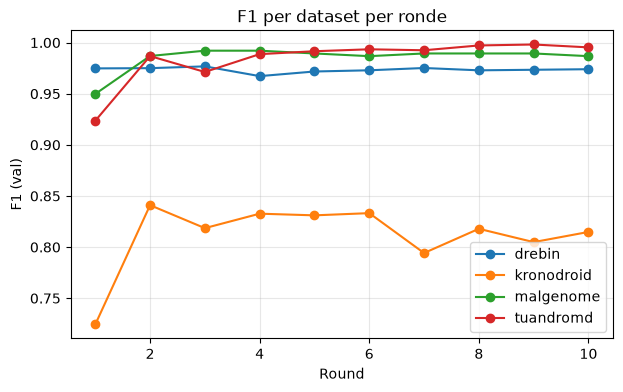

In [6]:
# =============================================================================
# Ekspor CSV: metrik per-ronde (accuracy, precision, recall, f1) + bandwidth
# =============================================================================
# run_federated() sudah otomatis mengekspor ke:
#   FedPer_metrics_per_round.csv   -> loss/accuracy/precision/recall/f1 + bandwidth per ronde
#   FedPer_val_per_client.csv      -> metrik val per client per ronde
# Path-nya juga tersimpan di dalam history:
print("Metrics per-round CSV :", h_fedper.get("metrics_csv_path"))
print("Per-client val CSV    :", h_fedper.get("per_client_csv_path"))

# Kalau mau simpan ke lokasi/nama lain secara eksplisit:
export_history_csv(h_fedper, "FedPer_metrics_per_round.csv")
export_per_client_csv(h_fedper, "FedPer_val_per_client.csv", split="val_per_client")

df_metrics = pd.read_csv("FedPer_metrics_per_round.csv")
print(df_metrics)

# %%
# =============================================================================
# Plot: F1 per dataset per ronde (dari val_per_client)
# =============================================================================
rows = []
for r, vc in zip(h_fedper["round"], h_fedper["val_per_client"]):
    for cname, m in vc.items():
        rows.append({"round": r, "dataset": cname, **m})
df_val = pd.DataFrame(rows)
df_val.to_csv("FedPer_val_per_client_long.csv", index=False)  # versi long-format, opsional

fig, ax = plt.subplots(figsize=(7, 4))
for cname, g in df_val.groupby("dataset"):
    ax.plot(g["round"], g["f1"], marker="o", label=cname)
ax.set_xlabel("Round"); ax.set_ylabel("F1 (val)")
ax.set_title("F1 per dataset per ronde"); ax.legend(); ax.grid(alpha=0.3)
plt.savefig("FedPer_f1_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

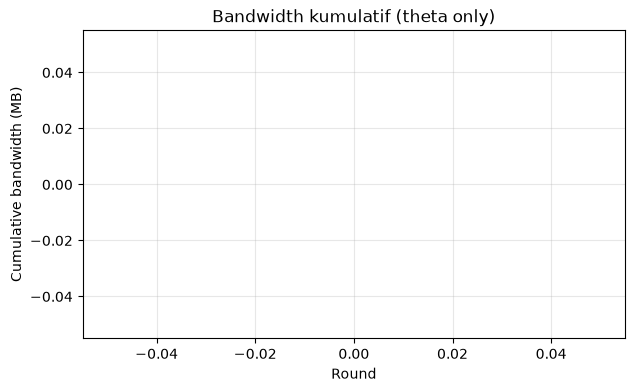

            accuracy  precision  recall      f1
dataset                                        
drebin        0.9800     0.9603  0.9868  0.9734
kronodroid    0.8334     0.9970  0.6875  0.8138
malgenome     0.9842     0.9737  0.9788  0.9763
tuandromd     0.9910     0.9981  0.9907  0.9944

CSV berhasil disimpan sebagai: test_per_client_fedper.csv

Semua file CSV yang dihasilkan:
 - FedPer_metrics_per_round.csv   (metrik + bandwidth per ronde)
 - FedPer_val_per_client.csv      (metrik val per client per ronde)
 - FedPer_val_per_client_long.csv (versi long-format untuk plotting)
 - test_per_client_fedper.csv     (metrik test akhir per client)


In [7]:
# =============================================================================
# Plot: Bandwidth kumulatif per ronde
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_metrics["round"], df_metrics["cum_MB"], marker="o", color="darkorange")
ax.set_xlabel("Round"); ax.set_ylabel("Cumulative bandwidth (MB)")
ax.set_title("Bandwidth kumulatif (theta only)"); ax.grid(alpha=0.3)
plt.savefig("FedPer_bandwidth_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()

# %%
# =============================================================================
# Ringkasan akhir: metrik test per client
# =============================================================================
df_test = pd.DataFrame(h_fedper["test_per_client"]).T
df_test.index.name = "dataset"
df_test = df_test[["accuracy", "precision", "recall", "f1"]].round(4)
print(df_test)

df_test.to_csv("test_per_client_fedper.csv", index=True)
print("\nCSV berhasil disimpan sebagai: test_per_client_fedper.csv")

print("\nSemua file CSV yang dihasilkan:")
print(" - FedPer_metrics_per_round.csv   (metrik + bandwidth per ronde)")
print(" - FedPer_val_per_client.csv      (metrik val per client per ronde)")
print(" - FedPer_val_per_client_long.csv (versi long-format untuk plotting)")
print(" - test_per_client_fedper.csv     (metrik test akhir per client)")